In [4]:
!wget https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv

--2026-04-26 16:25:06--  https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84143 (82K) [text/plain]
Saving to: ‘wineqr.csv’

wineqr.csv          100%[===================>]  82.17K  --.-KB/s    in 0.009s  

2026-04-26 16:25:06 (8.98 MB/s) - ‘wineqr.csv’ saved [84143/84143]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [5]:
df = pd.read_csv('wineqr.csv')
X = df.drop('quality', axis=1)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-MEANS

In [7]:
wcss = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f"K={k}: силуэт={sil:.3f}")


K=2: силуэт=0.214
K=3: силуэт=0.189
K=4: силуэт=0.172
K=5: силуэт=0.190
K=6: силуэт=0.195
K=7: силуэт=0.193
K=8: силуэт=0.150
K=9: силуэт=0.153
K=10: силуэт=0.157


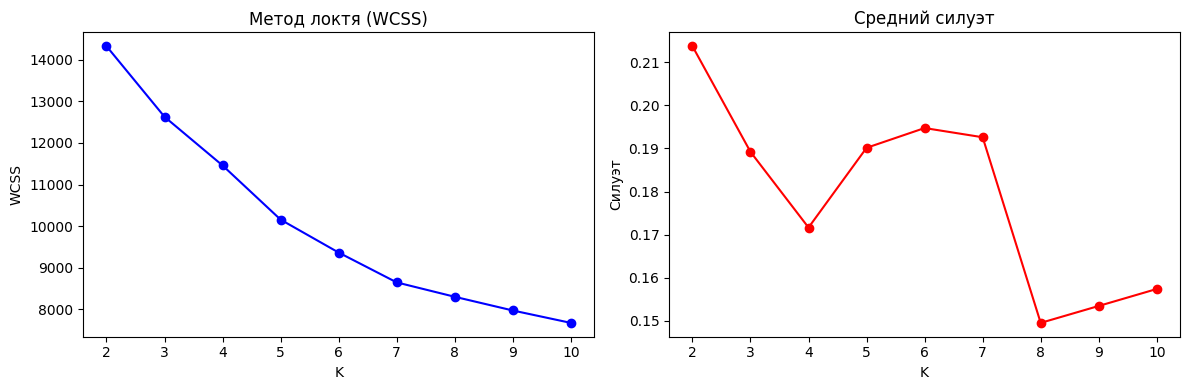

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, wcss, 'bo-')
ax1.set_title('Метод локтя (WCSS)')
ax1.set_xlabel('K')
ax1.set_ylabel('WCSS')
ax2.plot(K_range, sil_scores, 'ro-')
ax2.set_title('Средний силуэт')
ax2.set_xlabel('K')
ax2.set_ylabel('Силуэт')
plt.tight_layout()
plt.show()

In [9]:
best_k = K_range[sil_scores.index(max(sil_scores))]
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_scaled)

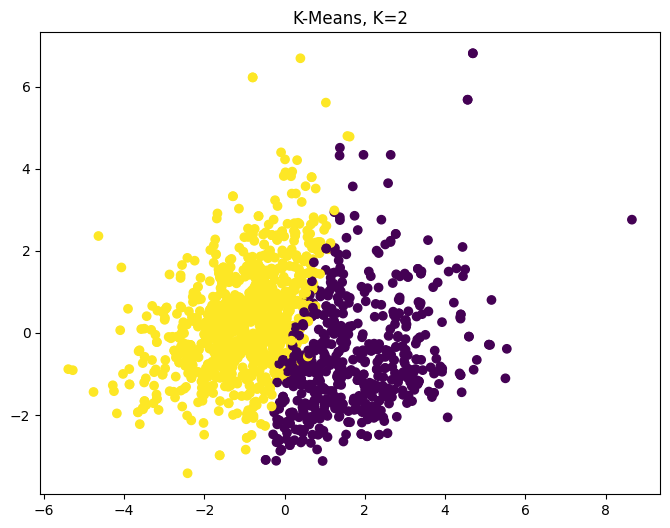

Финальный силуэт K-Means: 0.2137



In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=km_labels, cmap='viridis')
plt.title(f'K-Means, K={best_k}')
plt.show()

print(f"Финальный силуэт K-Means: {silhouette_score(X_scaled, km_labels):.4f}\n")

# DBSCAN

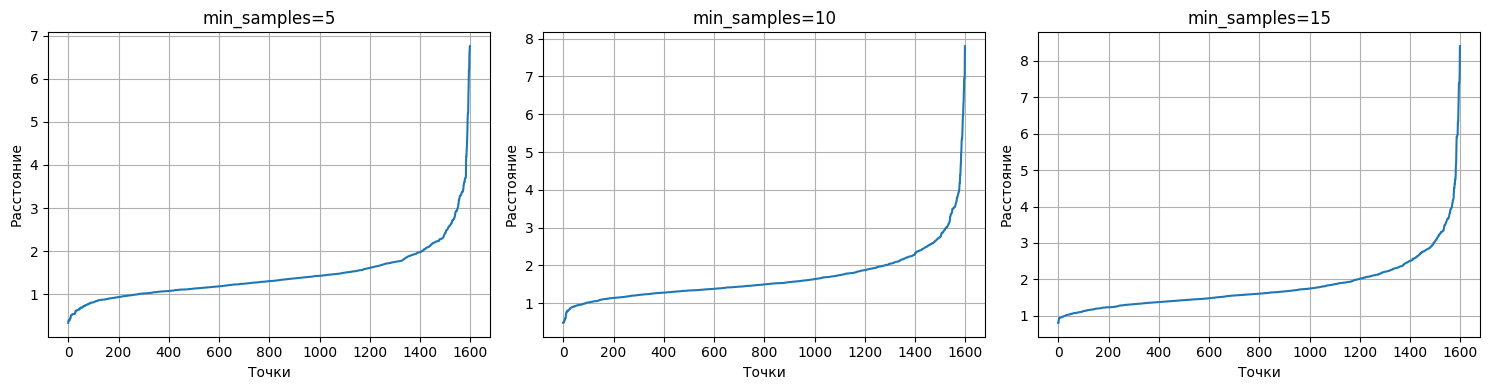

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, min_s in enumerate([5, 10, 15]):
    neigh = NearestNeighbors(n_neighbors=min_s)
    neigh.fit(X_scaled)
    distances, _ = neigh.kneighbors(X_scaled)
    k_dist = np.sort(distances[:, min_s-1])
    axes[i].plot(k_dist)
    axes[i].set_title(f'min_samples={min_s}')
    axes[i].set_xlabel('Точки')
    axes[i].set_ylabel('Расстояние')
    axes[i].grid(True)
plt.tight_layout()
plt.show()

In [12]:
best_sil = -1
best_eps = None
best_min = None

for min_s in [5, 10, 15]:
    for eps in [0.3, 0.5, 0.7, 0.9, 1.1]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).sum() / len(labels)

        if n_clusters >= 2 and noise_pct <= 0.8:
            mask = labels != -1
            if len(set(labels[mask])) > 1:
                sil = silhouette_score(X_scaled[mask], labels[mask])
                if sil > best_sil:
                    best_sil = sil
                    best_eps = eps
                    best_min = min_s
                    print(f"eps={eps}, min_samples={min_s}: кластеров={n_clusters}, шум={noise_pct:.0%}, силуэт={sil:.3f}")

eps=1.1, min_samples=5: кластеров=18, шум=59%, силуэт=-0.116
eps=1.1, min_samples=10: кластеров=7, шум=77%, силуэт=0.246


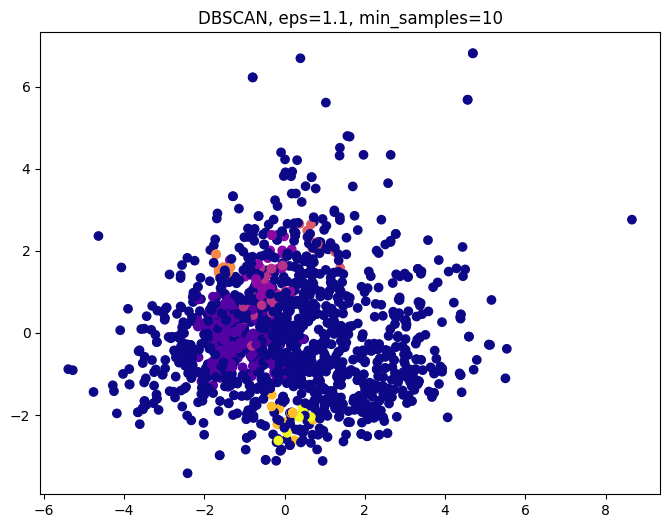

Лучший силуэт DBSCAN: 0.2456
Шумовых точек: 1234 (77.2%)



In [13]:
db_final = DBSCAN(eps=best_eps, min_samples=best_min)
db_labels = db_final.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels, cmap='plasma')
plt.title(f'DBSCAN, eps={best_eps}, min_samples={best_min}')
plt.show()

print(f"Лучший силуэт DBSCAN: {best_sil:.4f}")
print(f"Шумовых точек: {(db_labels == -1).sum()} ({(db_labels == -1).sum()/len(db_labels)*100:.1f}%)\n")

**Почему для DBSCAN критически важно масштабировать данные?**

DBSCAN использует евклидово расстояние. Без масштабирования признаки с большими значениями доминируют над мелкими.

**Что будет при слишком маленьком eps? Слишком большом?**

Слишком маленький Если eps слишком маленький, то почти все точки станут шумом, а если слишком большой — все точки сольются в один кластер.

**Что означают точки с меткой -1?**

Точки с меткой -1 обозначают шум (выбросы), не принадлежащие ни одному кластеру.

**Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?**

K-Means: только выпуклые сферические кластеры
DBSCAN: любые формы

# OPTICS

In [23]:
opt = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
opt_labels = opt.fit_predict(X_scaled)

n_clusters = len(set(opt_labels)) - (1 if -1 in opt_labels else 0)
n_noise = (opt_labels == -1).sum()
print(f"Кластеров: {n_clusters}")
print(f"Шумовых точек: {n_noise} ({n_noise/len(opt_labels)*100:.1f}%)")

mask = opt_labels != -1
if len(set(opt_labels[mask])) > 1:
    opt_sil = silhouette_score(X_scaled[mask], opt_labels[mask])
    print(f"Силуэт: {opt_sil:.4f}")

Кластеров: 1
Шумовых точек: 0 (0.0%)


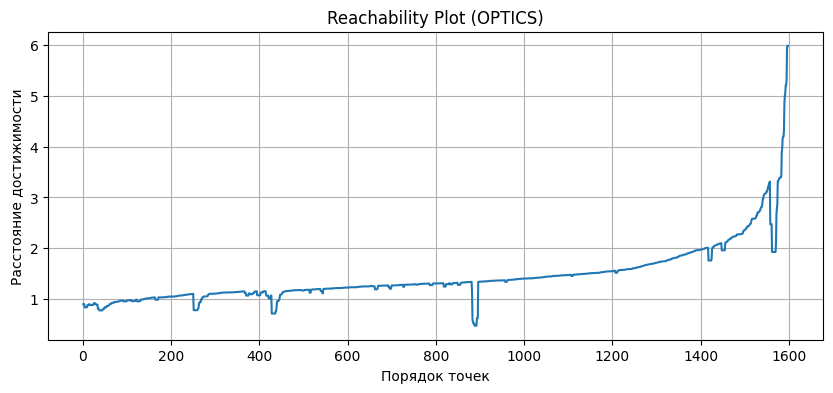

In [24]:
plt.figure(figsize=(10, 4))
plt.plot(opt.reachability_[opt.ordering_])
plt.title('Reachability Plot (OPTICS)')
plt.xlabel('Порядок точек')
plt.ylabel('Расстояние достижимости')
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'OPTICS')

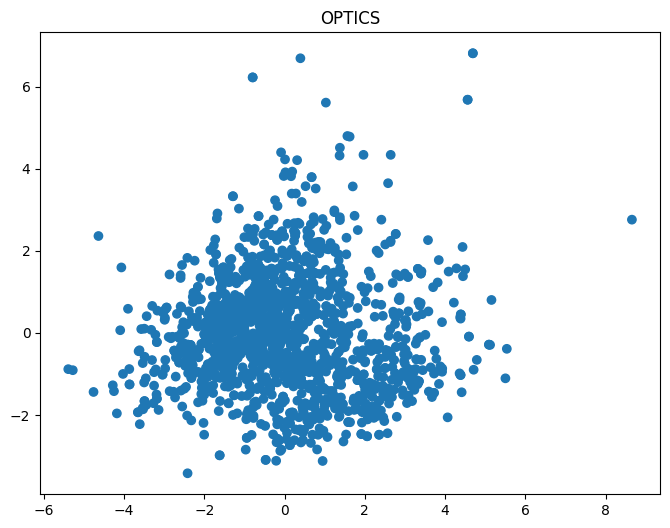

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=opt_labels, cmap='tab10')
plt.title('OPTICS')

In [19]:

%timeit DBSCAN(eps=0.5, min_samples=5).fit_predict(X_scaled)
%timeit OPTICS(min_samples=10, xi=0.05).fit_predict(X_scaled)

51.9 ms ± 10.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
1.77 s ± 218 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


**Чем OPTICS отличается от DBSCAN? Укажите два ключевых отличия.**

OPTICS не требует параметра eps (адаптируется под разную плотность)
OPTICS строит иерархию кластеров (reachability plot)

**Что такое параметр xi (кси) и как он влияет на выделение кластеров?**

Параметр xi - минимальная крутизна на графике достижимости.
Чем меньше xi, тем больше мелких кластеров.

**В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.**

OPTICS лучше DBSCAN, когда есть кластеры разной плотности.
Пример: плотное ядро + разреженное гало вокруг него.


**Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через %timeit или time.time()). **

DBSCAN: 52 мс (0.052 секунды)
OPTICS: 1.77 секунды
OPTICS медленнее DBSCAN примерно в 34 раза


**Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?**

DBSCAN. У него самый высокий силуэт (0.246 против 0.214 у K-Means). Кроме того, DBSCAN выявил, что 77% данных — это шум, а 23% образуют плотные кластеры. Это говорит о том, что данные имеют естественную структуру с выбросами, которую K-Means не может обнаружить (он принудительно разбивает все точки на 2 круглых кластера). OPTICS при выбранных параметрах не сработал (все точки в одном кластере). Для OPTICS нужен подбор параметров, при заданных он неэффективен.